# NB1 — SFT-mini: Build the Lab 21 SFT checkpoint inline

**Stack:** Unsloth + LoRA r=16 + bitsandbytes 4-bit base + 1k VN Alpaca, 1 epoch.
Maps to deck §1 (why SFT alone insufficient — motivates the upcoming DPO step) +
deck §3 (DPO will need this SFT checkpoint as initial policy).

> **Mục tiêu:** tạo 1 SFT adapter "đủ tốt" để DPO có gì align lên. Đây là
> Lab 21 thu gọn — nếu bạn đã hoàn thành Lab 21 sibling repo
> ([VinUni-AI20k/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA](https://github.com/VinUni-AI20k/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA)),
> bạn có thể SKIP notebook này và copy adapter cũ vào `adapters/sft-mini/`.
>
> Nếu chưa, notebook này build từ đầu trong ~10 phút trên T4 (15 phút trên Colab CPU runtime — *đừng làm vậy*).

## 0. Setup

In [1]:
import os
from pathlib import Path

# Tier detection. Defaults to T4 if env not set.
COMPUTE_TIER = os.environ.get("COMPUTE_TIER", "T4").upper()
assert COMPUTE_TIER in ("T4", "BIGGPU"), f"Invalid COMPUTE_TIER: {COMPUTE_TIER}"

# Tier-specific hyperparameters
if COMPUTE_TIER == "T4":
    BASE_MODEL = "unsloth/Qwen2.5-3B-bnb-4bit"
    MAX_LEN = 512
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 8
else:  # BIGGPU
    BASE_MODEL = "unsloth/Qwen2.5-7B-bnb-4bit"
    MAX_LEN = 1024
    PER_DEVICE_BATCH = 2
    GRAD_ACCUM = 4

SFT_DATASET = os.environ.get("SFT_DATASET", "5CD-AI/Vietnamese-alpaca-gpt4-gg-translated")
SFT_SLICE = 1000
NUM_EPOCHS = 1

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ADAPTER_OUT = REPO_ROOT / "adapters" / "sft-mini"
ADAPTER_OUT.mkdir(parents=True, exist_ok=True)

print(f"COMPUTE_TIER:    {COMPUTE_TIER}")
print(f"BASE_MODEL:      {BASE_MODEL}")
print(f"SFT_DATASET:     {SFT_DATASET}  (slice: {SFT_SLICE})")
print(f"max_seq_length:  {MAX_LEN}")
print(f"effective batch: {PER_DEVICE_BATCH * GRAD_ACCUM}")
print(f"output:          {ADAPTER_OUT}")

COMPUTE_TIER:    BIGGPU
BASE_MODEL:      unsloth/Qwen2.5-7B-bnb-4bit
SFT_DATASET:     5CD-AI/Vietnamese-alpaca-gpt4-gg-translated  (slice: 1000)
max_seq_length:  1024
effective batch: 8
output:          /root/Day22-Track3-DPO-Alignment-Lab/adapters/sft-mini


In [2]:
import torch

assert torch.cuda.is_available(), "DPO needs a CUDA GPU. See HARDWARE-GUIDE.md."
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}  ({gpu.total_memory / 1e9:.1f} GB)")

GPU: NVIDIA GeForce RTX 3090  (25.3 GB)


## 1. Load base model with Unsloth

Unsloth bundles patched 4-bit kernels — that's how Qwen2.5-3B (or 7B) stays
in T4 / A100 budget. The `FastLanguageModel.from_pretrained` call returns a
4-bit quantized base; `get_peft_model` attaches the LoRA adapter on top.

In [3]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_LEN,
    dtype=None,                # auto: bf16 on Ampere+, fp16 on Turing
    load_in_4bit=True,
)

# Critical for batch training — Qwen tokenizers ship without pad token.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Set tokenizer.pad_token = eos_token")


def render_chat(messages, *, add_generation_prompt=False, return_tensors=None):
    if tokenizer.chat_template:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=return_tensors is not None,
            return_tensors=return_tensors,
            add_generation_prompt=add_generation_prompt,
        )

    text = "".join(
        f"<|im_start|>{message['role']}\n{message['content']}<|im_end|>\n"
        for message in messages
    )
    if add_generation_prompt:
        text += "<|im_start|>assistant\n"
    if return_tensors is not None:
        return tokenizer(text, return_tensors=return_tensors).input_ids
    return text

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/root/Day22-Track3-DPO-Alignment-Lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!


[unsloth_zoo.log|WARNING]Unsloth: Could not patch trl.trainer.grpo_trainer: Direct module loading failed for UnslothGRPOTrainer: Unexpected optimization option triton.enable_persistent_tma_matmul, known options are ['TYPE_CHECKING', 'enable_auto_functionalized_v2', 'debug', 'disable_progress', 'verbose_progress', 'fx_graph_cache', 'fx_graph_remote_cache', 'autotune_local_cache', 'autotune_remote_cache', 'force_disable_caches', 'sleep_sec_TESTING_ONLY', 'custom_op_default_layout_constraint', 'cpp_wrapper', 'abi_compatible', 'c_shim_version', 'dce', 'static_weight_shapes', 'size_asserts', 'nan_asserts', 'pick_loop_orders', 'inplace_buffers', 'allow_buffer_reuse', 'memory_planning', 'memory_pool', 'benchmark_harness', 'epilogue_fusion', 'epilogue_fusion_first', 'pattern_matcher', 'b2b_gemm_pass', 'post_grad_custom_pre_pass', 'post_grad_custom_post_pass', 'joint_custom_pre_pass', 'joint_custom_post_pass', 'pre_grad_custom_pass', '_pre_fusion_custom_pass', 'split_cat_fx_passes', 'efficient_

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 23.569 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 8.6. CUDA Toolkit: 12.1. Triton: 3.1.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


unsloth/Qwen2.5-7B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [4]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.0,           # Unsloth supports dropout=0 for free speed
    bias="none",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    use_gradient_checkpointing="unsloth",  # 30% VRAM savings
    random_state=42,
    use_rslora=False,
    loftq_config=None,
)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Trainable params: 40,370,176


## 2. Load + format VN Alpaca slice

`5CD-AI/Vietnamese-alpaca-gpt4-gg-translated` is a VN Alpaca translation. Lab 21
uses 1k slice for the demo run; we match that exactly so reward gap is comparable.

In [5]:
from datasets import load_dataset

ds = load_dataset(SFT_DATASET, split=f"train[:{SFT_SLICE}]")
print(f"Loaded {len(ds)} rows. Columns: {ds.column_names}")
print(f"\nFirst row:\n{ds[0]}")

Generating train split:   0%|                  | 0/52002 [00:00<?, ? examples/s]

Generating train split: 100%|███| 52002/52002 [00:02<00:00, 22201.35 examples/s]

Generating train split: 100%|███| 52002/52002 [00:02<00:00, 22167.43 examples/s]

Loaded 1000 rows. Columns: ['input_en', 'input_vi', 'instruction_vi', 'output_vi', 'output_en', 'instruction_en']

First row:
{'input_en': '', 'input_vi': '', 'instruction_vi': 'Đưa ra ba lời khuyên để giữ sức khỏe.', 'output_vi': '1. Ăn một chế độ ăn uống cân bằng và bổ dưỡng: Đảm bảo bữa ăn của bạn bao gồm nhiều loại trái cây và rau quả, protein nạc, ngũ cốc nguyên hạt và chất béo lành mạnh. Điều này giúp cung cấp cho cơ thể bạn các chất dinh dưỡng cần thiết để hoạt động tốt nhất và có thể giúp ngăn ngừa các bệnh mãn tính. 2. Tham gia hoạt động thể chất thường xuyên: Tập thể dục rất quan trọng để duy trì xương, cơ bắp và sức khỏe tim mạch chắc khỏe. Đặt mục tiêu tập thể dục nhịp điệu vừa phải ít nhất 150 phút hoặc tập thể dục cường độ cao 75 phút mỗi tuần. 3. Ngủ đủ giấc: Ngủ đủ giấc là điều rất quan trọng để có được sức khỏe thể chất và tinh thần. Nó giúp điều chỉnh tâm trạng, cải thiện chức năng nhận thức và hỗ trợ tăng trưởng khỏe mạnh và chức năng miễn dịch. Đặt mục tiêu ngủ 7-9 

In [6]:
# Alpaca → ChatML format (Qwen2.5's native template)
def format_alpaca_to_chat(row):
    messages = []
    instruction = row.get("instruction") or row.get("instruction_vi") or row.get("instruction_en")
    input_text = row.get("input") or row.get("input_vi") or row.get("input_en")
    output = row.get("output") or row.get("output_vi") or row.get("output_en")

    if instruction:
        prompt = instruction
        if input_text:
            prompt += "\n\n" + input_text
        messages.append({"role": "user", "content": prompt})
    if output:
        messages.append({"role": "assistant", "content": output})
    text = render_chat(messages, add_generation_prompt=False)
    return {"text": text}


ds_formatted = ds.map(format_alpaca_to_chat, remove_columns=ds.column_names)
ds_formatted = ds_formatted.filter(lambda row: bool(row["text"].strip()))
print(f"Formatted {len(ds_formatted)} non-empty rows.")
print(f"\nSample formatted text (first 500 chars):\n{ds_formatted[0]['text'][:500]}")

Map:   0%|                                      | 0/1000 [00:00<?, ? examples/s]

Map: 100%|████████████████████████| 1000/1000 [00:00<00:00, 15826.43 examples/s]

Filter:   0%|                                   | 0/1000 [00:00<?, ? examples/s]

Filter: 100%|████████████████████| 1000/1000 [00:00<00:00, 139133.02 examples/s]

Formatted 1000 non-empty rows.

Sample formatted text (first 500 chars):
<|im_start|>user
Đưa ra ba lời khuyên để giữ sức khỏe.<|im_end|>
<|im_start|>assistant
1. Ăn một chế độ ăn uống cân bằng và bổ dưỡng: Đảm bảo bữa ăn của bạn bao gồm nhiều loại trái cây và rau quả, protein nạc, ngũ cốc nguyên hạt và chất béo lành mạnh. Điều này giúp cung cấp cho cơ thể bạn các chất dinh dưỡng cần thiết để hoạt động tốt nhất và có thể giúp ngăn ngừa các bệnh mãn tính. 2. Tham gia hoạt động thể chất thường xuyên: Tập thể dục rất quan trọng để duy trì xương, cơ bắp và sức khỏe tim m


## 3. Train SFT-mini

In [7]:
from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir=str(ADAPTER_OUT.parent / "sft-mini-checkpoints"),
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=10,
    save_strategy="no",        # Save only at the end via trainer.model.save_pretrained
    optim="adamw_8bit",
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    seed=42,
    max_seq_length=MAX_LEN,
    dataset_text_field="text",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    args=sft_config,
    train_dataset=ds_formatted,
)

/tmp/unsloth_compiled_cache/UnslothSFTTrainer.py:859: UserWarning: Padding-free training is enabled, but the attention implementation is not set to 'flash_attention_2'. Padding-free training flattens batches into a single sequence, and 'flash_attention_2' is the only known attention mechanism that reliably supports this. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation='flash_attention_2'` in the model configuration, or verify that your attention mechanism can handle flattened sequences.
  warnings.warn(


Unsloth: Tokenizing ["text"] (num_proc=64):   0%| | 0/1000 [00:00<?, ? examples/

Unsloth: Tokenizing ["text"] (num_proc=64):   2%| | 16/1000 [00:00<00:38, 25.69 

Unsloth: Tokenizing ["text"] (num_proc=64):   3%| | 32/1000 [00:00<00:19, 49.71 

Unsloth: Tokenizing ["text"] (num_proc=64):   5%| | 48/1000 [00:00<00:13, 70.48 

...

Unsloth: Tokenizing ["text"] (num_proc=64):  94%|▉| 940/1000 [00:05<00:00, 206.3

Unsloth: Tokenizing ["text"] (num_proc=64):  97%|▉| 970/1000 [00:06<00:00, 197.5

Unsloth: Tokenizing ["text"] (num_proc=64): 100%|█| 1000/1000 [00:06<00:00, 184.

Unsloth: Tokenizing ["text"] (num_proc=64): 100%|█| 1000/1000 [00:06<00:00, 155.

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [8]:
train_result = trainer.train()
print(f"\nFinal train loss: {train_result.training_loss:.4f}")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 1 | Total steps = 125
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)


Step,Training Loss
10,1.804800
20,1.633700
30,1.472400
40,1.495500
50,1.429100
60,1.376300
70,1.376400
80,1.430000
90,1.366800
100,1.429200



Final train loss: 1.4741


### 3a. Plot loss curve (deliverable: `02_sft_loss.png`)

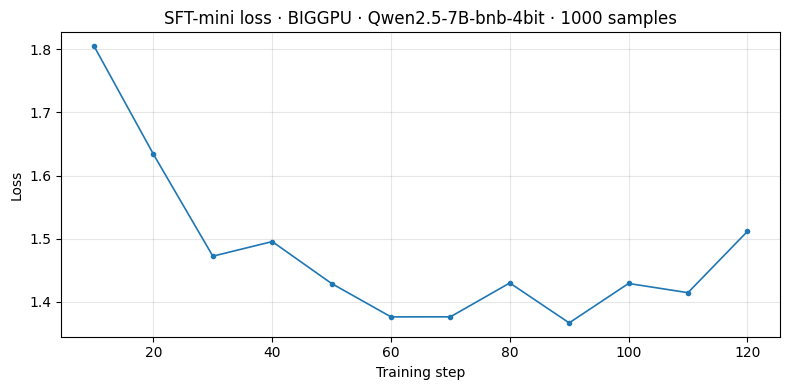

In [9]:
import matplotlib.pyplot as plt

losses = [log["loss"] for log in trainer.state.log_history if "loss" in log]
steps = [log["step"] for log in trainer.state.log_history if "loss" in log]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, losses, marker="o", markersize=3, linewidth=1.2)
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_title(f"SFT-mini loss · {COMPUTE_TIER} · {BASE_MODEL.split('/')[-1]} · {SFT_SLICE} samples")
ax.grid(True, alpha=0.3)
fig.tight_layout()
screenshot_dir = REPO_ROOT / "submission" / "screenshots"
screenshot_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(screenshot_dir / "02-sft-loss.png", dpi=120)
plt.show()

## 4. Save adapter + sanity-check generation

In [10]:
trainer.model.save_pretrained(str(ADAPTER_OUT))
tokenizer.save_pretrained(str(ADAPTER_OUT))
print(f"Saved SFT adapter to {ADAPTER_OUT}")

Saved SFT adapter to /root/Day22-Track3-DPO-Alignment-Lab/adapters/sft-mini


In [11]:
# Sanity: generate 1 sample to confirm the adapter loaded correctly.
FastLanguageModel.for_inference(model)
prompt = "Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào."
messages = [{"role": "user", "content": prompt}]
inputs = render_chat(messages, return_tensors="pt", add_generation_prompt=True).to("cuda")
with torch.no_grad():
    out = model.generate(input_ids=inputs, max_new_tokens=200, do_sample=False)
generated = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
print(f"PROMPT: {prompt}\n")
print(f"SFT-mini response:\n{generated}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


PROMPT: Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào.

SFT-mini response:
Thuật toán quicksort là một thuật toán sắp xếp nhanh chóng và hiệu quả, hoạt động bằng cách chia mảng cần sắp xếp thành hai phần, một phần chứa các phần tử nhỏ hơn phần tử trung tâm và một phần chứa các phần tử lớn hơn phần tử trung tâm. Quá trình này được lặp lại cho từng phần cho đến khi tất cả các phần đều có kích thước bằng 1 hoặc nhỏ hơn. Quy trình này được gọi là chia. Sau đó, các phần được sắp xếp lại theo thứ tự tăng dần, kết quả là mảng đã được sắp xếp. Quy trình này được gọi là hợp nhất. Quy trình này được lặp lại cho đến khi tất cả các phần đều được sắp xếp. Quy trình này được gọi là chia và hợp nhất. Quy trình này được lặp lại cho đến khi tất cả các phần đều được sắp xếp. Quy trình này được gọi là chia và


## 5. Vibe-coding callout

Bạn vừa tái tạo Lab 21 trong ~10 phút. Một câu hỏi để brainstorm:

> **Thật ra, bạn cần *bao nhiêu* SFT để DPO có ý nghĩa?**
>
> Thử thay `SFT_SLICE = 1000` → `100`. Re-run NB1 → NB3 với SFT yếu hơn.
> Quan sát: reward gap có còn tăng được không? Output coherent không?
>
> Đây là 1 design decision *think-hard zone* (xem VIBE-CODING.md): không có
> đáp án sẵn trong deck. Hypothesize trước, train sau, viết kết quả vào
> `submission/REFLECTION.md` § 6.

**Next:** NB2 — load + format preference data.